# **Grid Search – Hyperparameter Optimization**

##  Introduction
In machine learning, **model performance** often depends heavily on choosing the right **hyperparameters** — parameters that are *not learned* during training but are set *before* training (e.g., learning rate, number of neighbors, depth of a tree).

**Grid Search** is a simple but powerful method for finding the *best* combination of hyperparameters by testing *all possible combinations* over a defined search space.

---

##  Intuition
Let’s say we want to tune a model with 2 hyperparameters:

| Hyperparameter | Possible Values |
|----------------|------------------|
| `learning_rate` | [0.01, 0.1, 0.5] |
| `max_depth` | [2, 4, 6] |

Grid search will train and evaluate the model on *every combination*:

| learning_rate | max_depth |
|----------------|-----------|
| 0.01 | 2 |
| 0.01 | 4 |
| 0.01 | 6 |
| 0.1  | 2 |
| 0.1  | 4 |
| 0.1  | 6 |
| 0.5  | 2 |
| 0.5  | 4 |
| 0.5  | 6 |

Then it picks the one that gives the **best performance** on validation data.

---

##  Why Do We Need It?
- Because manually guessing hyperparameters is inefficient.
- Helps **automate** the tuning process.
- Ensures **fair evaluation** over a consistent search space.

---

##  Pros & Cons

 **Pros**
- Simple to implement  
- Guarantees best combination within search grid  
- Works with any model  

 **Cons**
- Computationally expensive  
- Doesn’t scale well with large parameter spaces  
- Can overfit if validation data is reused too much  

---

##  Real-world Analogy
Think of grid search like **trying all combinations of spices** in a recipe until you find the tastiest one  — it’s systematic but can take a lot of time!




# **Imports & Dataset Generation**

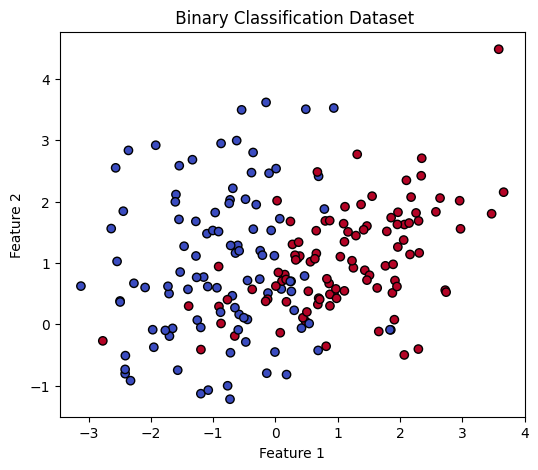

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


plt.figure(figsize=(6,5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title(" Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# **Implmentation**

In [2]:
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from itertools import product

def custom_grid_search(model_class, param_grid, X_train, y_train, X_val, y_val):
    best_score = -np.inf
    best_params = None
    results = []

    #  generate all combinations of parameters
    keys = list(param_grid.keys())
    for values in product(*param_grid.values()):
        params = dict(zip(keys, values))

        # train model
        model = model_class(**params)
        model.fit(X_train, y_train)

        # evaluate on validation set
        y_pred = model.predict(X_val)
        score = accuracy_score(y_val, y_pred)
        results.append((params, score))

        print(f"Params: {params} -> Accuracy: {score:.3f}")

        # track best combination
        if score > best_score:
            best_score = score
            best_params = params

    return best_params, best_score, results


In [3]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# define parameter grid
param_grid = {
    'n_neighbors': [1, 3, 5, 7, 9],
    'weights': ['uniform', 'distance']
}

# run grid search
best_params, best_score, results = custom_grid_search(
    KNeighborsClassifier, param_grid,
    X_train_sub, y_train_sub,
    X_val, y_val
)

print("\n Best Parameters Found:")
print(best_params)
print(f"Best Validation Accuracy: {best_score:.3f}")


Params: {'n_neighbors': 1, 'weights': 'uniform'} -> Accuracy: 0.857
Params: {'n_neighbors': 1, 'weights': 'distance'} -> Accuracy: 0.857
Params: {'n_neighbors': 3, 'weights': 'uniform'} -> Accuracy: 0.929
Params: {'n_neighbors': 3, 'weights': 'distance'} -> Accuracy: 0.929
Params: {'n_neighbors': 5, 'weights': 'uniform'} -> Accuracy: 0.857
Params: {'n_neighbors': 5, 'weights': 'distance'} -> Accuracy: 0.893
Params: {'n_neighbors': 7, 'weights': 'uniform'} -> Accuracy: 0.893
Params: {'n_neighbors': 7, 'weights': 'distance'} -> Accuracy: 0.893
Params: {'n_neighbors': 9, 'weights': 'uniform'} -> Accuracy: 0.857
Params: {'n_neighbors': 9, 'weights': 'distance'} -> Accuracy: 0.893

 Best Parameters Found:
{'n_neighbors': 3, 'weights': 'uniform'}
Best Validation Accuracy: 0.929


In [4]:
from sklearn.model_selection import GridSearchCV

# Define model and grid
model = KNeighborsClassifier()
grid = GridSearchCV(model, param_grid, cv=3, scoring='accuracy')

grid.fit(X_train, y_train)

print("\n Sklearn GridSearchCV Results:")
print(grid.best_params_)
print(f"Best Accuracy: {grid.best_score_:.3f}")


 Sklearn GridSearchCV Results:
{'n_neighbors': 9, 'weights': 'uniform'}
Best Accuracy: 0.858
